Data Types:
 metacritic_score    int64
pct_pos_total       int64
user_score          int64
score_diff          int64
dtype: object
Shape: (89618, 4)


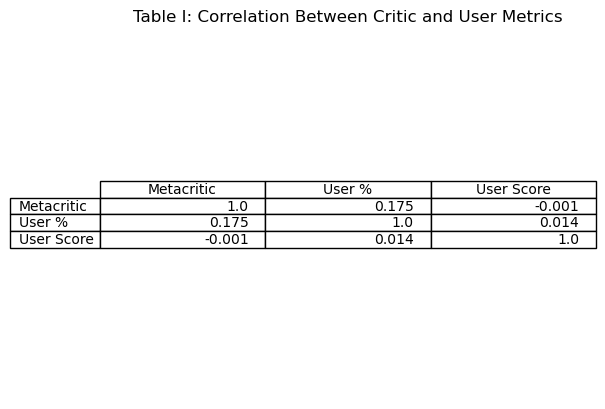

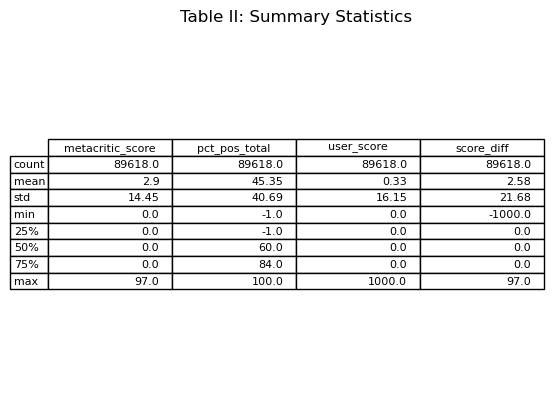

C:\Users\hites\AppData\Local\Temp\ipykernel_46512\767114688.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = rq3.groupby('disagreement')[['metacritic_score','user_score']].mean()


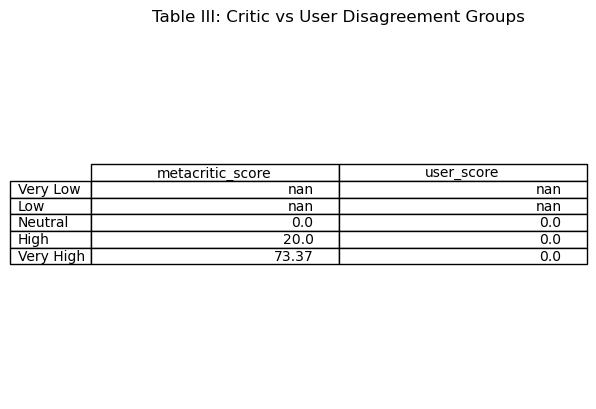

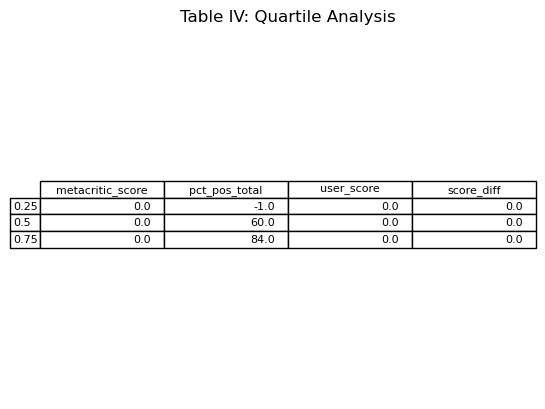

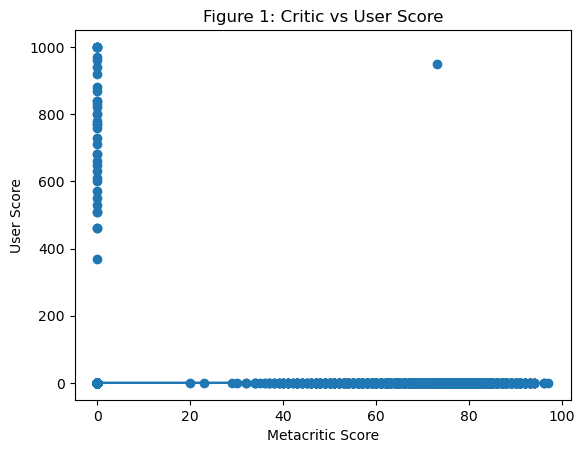

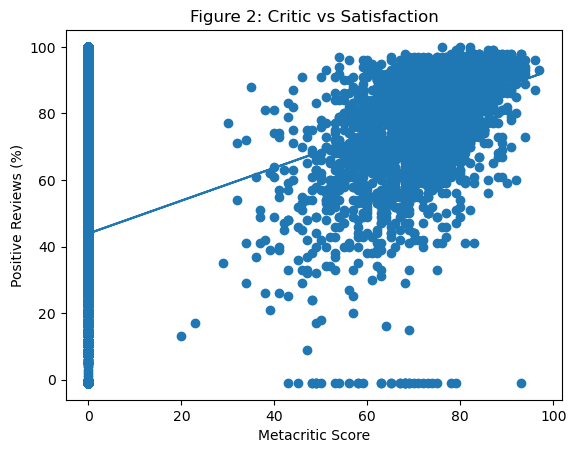

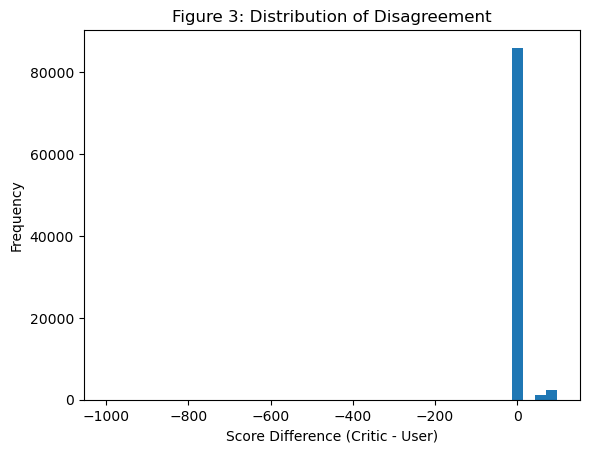

C:\Users\hites\AppData\Local\Temp\ipykernel_46512\767114688.py:141: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rq3['metacritic_score'], rq3['user_score']],


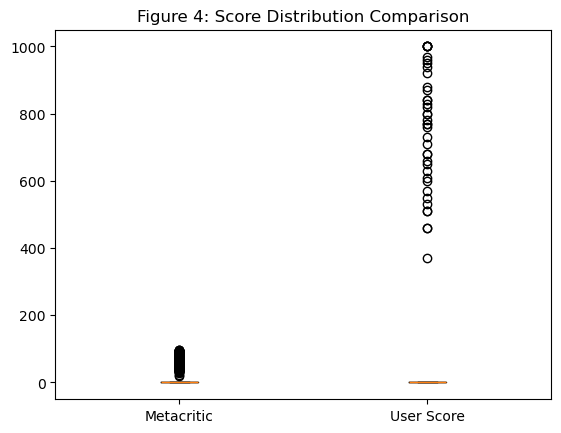

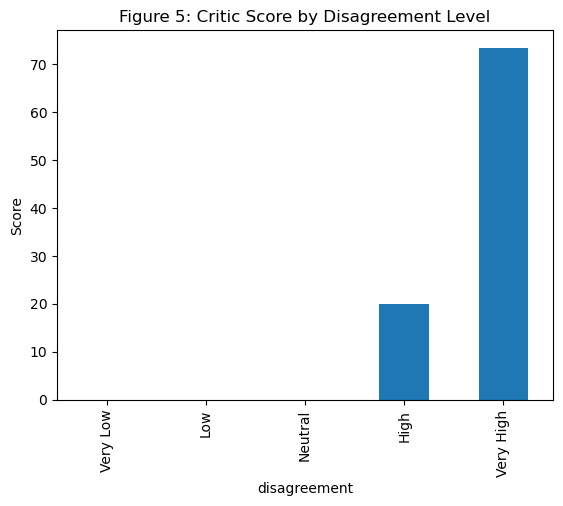

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset (FIX PATH IF NEEDED)
df = pd.read_csv(r'games_march2025_cleaned.csv')
df = df.drop_duplicates()


# DATA CLEANING (CRITICAL FIX)

cols = ['metacritic_score', 'pct_pos_total', 'user_score']

# Convert to numeric safely (handles strings like 'tbd', 'N/A')
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop invalid rows
rq3 = df[cols].dropna()

# Normalize user score (0–10 → 0–100)
rq3['user_score'] = rq3['user_score'] * 10

# Create disagreement feature
rq3['score_diff'] = rq3['metacritic_score'] - rq3['user_score']

# DEBUG CHECK (optional)

print("Data Types:\n", rq3.dtypes)
print("Shape:", rq3.shape)


# TABLE 1: CORRELATION

corr = rq3[['metacritic_score','pct_pos_total','user_score']].corr()

plt.figure()
plt.axis('off')
plt.table(cellText=np.round(corr.values,3),
          colLabels=['Metacritic','User %','User Score'],
          rowLabels=['Metacritic','User %','User Score'],
          loc='center')
plt.title('Table I: Correlation Between Critic and User Metrics')
plt.savefig('RQ3_Table1_Correlation.png', dpi=300, bbox_inches='tight')
plt.show()


# TABLE 2: SUMMARY STATS

summary = rq3.describe()

plt.figure()
plt.axis('off')
plt.table(cellText=np.round(summary.values,2),
          colLabels=summary.columns,
          rowLabels=summary.index,
          loc='center')
plt.title('Table II: Summary Statistics')
plt.savefig('RQ3_Table2_Summary.png', dpi=300, bbox_inches='tight')
plt.show()


# TABLE 3: DISAGREEMENT GROUPS

rq3['disagreement'] = pd.cut(rq3['score_diff'],
                            bins=[-100,-20,-5,5,20,100],
                            labels=['Very Low','Low','Neutral','High','Very High'])

group = rq3.groupby('disagreement')[['metacritic_score','user_score']].mean()

plt.figure()
plt.axis('off')
plt.table(cellText=np.round(group.values,2),
          colLabels=group.columns,
          rowLabels=group.index,
          loc='center')
plt.title('Table III: Critic vs User Disagreement Groups')
plt.savefig('RQ3_Table3_Disagreement.png', dpi=300, bbox_inches='tight')
plt.show()


# TABLE 4: QUANTILES (FIXED)

quantiles = rq3[['metacritic_score','pct_pos_total','user_score','score_diff']].quantile([0.25,0.5,0.75])

plt.figure()
plt.axis('off')
plt.table(cellText=np.round(quantiles.astype(float).values,2),
          colLabels=quantiles.columns,
          rowLabels=quantiles.index,
          loc='center')
plt.title('Table IV: Quartile Analysis')
plt.savefig('RQ3_Table4_Quantiles.png', dpi=300, bbox_inches='tight')
plt.show()


# FIGURE 1: CRITIC vs USER

plt.figure()
plt.scatter(rq3['metacritic_score'], rq3['user_score'])

z = np.polyfit(rq3['metacritic_score'], rq3['user_score'], 1)
p = np.poly1d(z)
plt.plot(rq3['metacritic_score'], p(rq3['metacritic_score']))

plt.xlabel('Metacritic Score')
plt.ylabel('User Score')
plt.title('Figure 1: Critic vs User Score')
plt.savefig('RQ3_Fig1_Critic_vs_User.png', dpi=300, bbox_inches='tight')
plt.show()


# FIGURE 2: CRITIC vs SATISFACTION

plt.figure()
plt.scatter(rq3['metacritic_score'], rq3['pct_pos_total'])

z = np.polyfit(rq3['metacritic_score'], rq3['pct_pos_total'], 1)
p = np.poly1d(z)
plt.plot(rq3['metacritic_score'], p(rq3['metacritic_score']))

plt.xlabel('Metacritic Score')
plt.ylabel('Positive Reviews (%)')
plt.title('Figure 2: Critic vs Satisfaction')
plt.savefig('RQ3_Fig2_Critic_vs_Satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()

# FIGURE 3: SCORE DIFFERENCE HISTOGRAM
plt.figure()
plt.hist(rq3['score_diff'], bins=40)

plt.xlabel('Score Difference (Critic - User)')
plt.ylabel('Frequency')
plt.title('Figure 3: Distribution of Disagreement')
plt.savefig('RQ3_Fig3_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# FIGURE 4: BOXPLOT

plt.figure()
plt.boxplot([rq3['metacritic_score'], rq3['user_score']],
            labels=['Metacritic','User Score'])

plt.title('Figure 4: Score Distribution Comparison')
plt.savefig('RQ3_Fig4_Boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# FIGURE 5: BAR CHART

plt.figure()
group['metacritic_score'].plot(kind='bar')

plt.title('Figure 5: Critic Score by Disagreement Level')
plt.ylabel('Score')
plt.savefig('RQ3_Fig5_Disagreement_Bar.png', dpi=300, bbox_inches='tight')
plt.show()
